In [47]:
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import Polynomial
import numpy as np

# Load the CSV
df_results = pd.read_csv(r"C:\Users\Ro\Desktop\qDriftExtraPolation\qdrift_ising_model_sweep_ultimate_2025-07-10.csv")
df_results

,Num Qubits,Time,Shots,Num Ancilla,Exact Eigenvalue,Expected Phase,Most Probable Bitstring,Estimated Phase,Estimated Eigenvalue,Eigenvalue Error,...,type of Hamiltonian,Num Random Circuits,Num Shots per Circuit,Circuit Depth,Raw results,estimnated energies counts,max energy,min energy,stdev energy,mean energy
0,2,-0.102183,100,10,(1.2806248474865685+0j),0.979173,1111101010,-0.021484,1.321059,0.040434,...,Ising,100,1,1026,"{'1111101000': 6, '1111110100': 1, '0000010101...","{np.float64(1.4411550999938634): 6, np.float64...",24.199396,-20.356316,4.683262,1.358289
1,2,-0.235561,100,10,(1.2806248474865685+0j),0.951988,1111001100,-0.050781,1.354503,0.073878,...,Ising,100,1,1026,"{'1100110101': 2, '1111000101': 3, '1111101110...","{np.float64(5.287770355207964): 2, np.float64(...",12.242621,-13.024065,3.299799,1.093500
2,2,-0.102183,100,10,(2.561249694973137+0j),0.958346,1111011101,-0.045410,2.792238,0.230988,...,Ising,100,1,1026,"{'1110101110': 1, '1111001001': 1, '1110101100...","{np.float64(4.9239465916456995): 1, np.float64...",29.123343,-29.603728,7.618976,2.781429
3,2,-0.337644,100,10,(1.2806248474865685+0j),0.931182,1111010011,-0.067871,1.263008,0.017617,...,Ising,100,1,1026,"{'1111010011': 3, '1111001001': 3, '1110110100...","{np.float64(0.8177747595250995): 3, np.float64...",8.395821,-5.815287,2.252179,1.281726
4,2,-0.235561,100,10,(2.561249694973137+0j),0.903977,1101010111,-0.099121,2.643885,0.082635,...,Ising,100,1,1026,"{'1111111000': 1, '1110000110': 1, '0001011011...","{np.float64(0.20838503862888527): 1, np.float6...",10.940215,-11.617466,4.559019,2.397470
5,2,-0.337644,100,10,(2.561249694973137+0j),0.862364,1110111001,-0.141113,2.625966,0.064716,...,Ising,100,1,1026,"{'1010010011': 1, '1100001111': 1, '1101101100...","{np.float64(6.633061938370251): 1, np.float64(...",8.922831,-9.068213,4.149868,1.951756
6,2,-0.392891,100,10,(1.2806248474865685+0j),0.919922,1110111001,-0.098633,1.577356,0.296731,...,Ising,100,1,1026,"{'1100111101': 1, '0001001111': 1, '1110101011...","{np.float64(3.045390129981589): 1, np.float64(...",7.605667,-6.809180,2.507490,1.667156
7,2,-0.392891,100,10,(2.561249694973137+0j),0.839844,1101011111,-0.156250,2.498782,0.062468,...,Ising,100,1,1026,"{'1101100001': 1, '0010100111': 1, '1111100111...","{np.float64(2.483164259831142): 1, np.float64(...",7.980484,-7.886780,3.952694,1.410406
8,2,0.392891,100,10,(2.561249694973137+0j),0.160156,10110100,0.213867,3.420207,0.858958,...,Ising,100,1,1026,"{'0010100010': 1, '1100010001': 1, '0011011000...","{np.float64(2.530016415677012): 1, np.float64(...",7.808693,-7.996101,3.777959,2.342139
9,2,0.392891,100,10,(1.2806248474865685+0j),0.080078,1110010,0.070801,1.132260,0.148364,...,Ising,100,1,1026,"{'0001010001': 1, '1111100000': 1, '0001000101...","{np.float64(1.265008207838506): 1, np.float64(...",7.355788,-7.949249,2.806061,1.097277


Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 10
Exact Eigenvalue: 2.561249694973137
Alpha: 3.6
Num Ancilla: 10


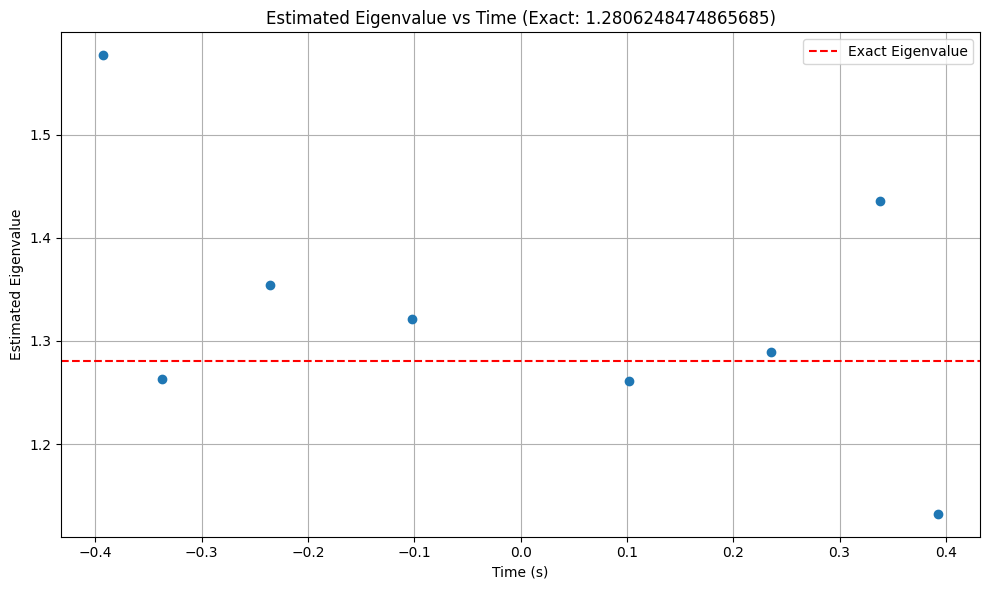

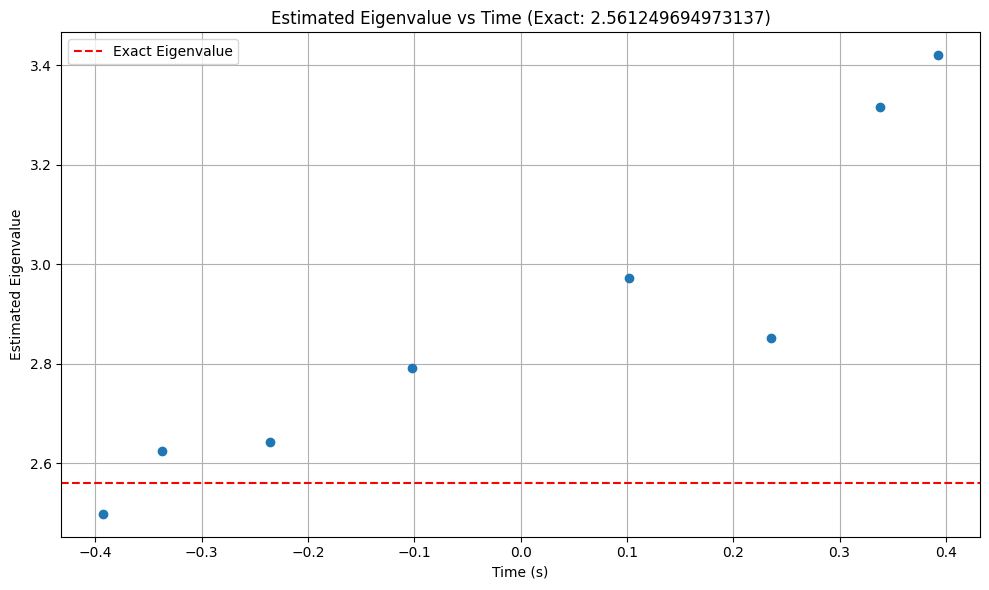

In [58]:
# plot estimated eigenvalue vs time and show some metadata
import ast
import re
for group_name, group in df_results.groupby("Exact Eigenvalue"):

    exact_eigenvalue = ast.literal_eval(group_name).real
    print(f"Exact Eigenvalue: {exact_eigenvalue}")
    alpha = group["Alpha"].iloc[0]
    print(f"Alpha: {alpha}")
    num_ancilla = group["Num Ancilla"].iloc[0]
    print(f"Num Ancilla: {num_ancilla}")

    stdevs = group["stdev energy"]
    stdev_theoretical_upper_bound = (alpha ** 2 * group["Time"] ** 2) * (2 ** (num_ancilla) - 1)


    plt.figure(figsize=(10, 6))
    plt.plot(group["Time"], group["Estimated Eigenvalue"], marker='o', linestyle='None')
    plt.axhline(y=exact_eigenvalue, color='r', linestyle='--', label='Exact Eigenvalue')
    plt.xlabel("Time (s)")
    plt.ylabel("Estimated Eigenvalue")
    plt.title(f"Estimated Eigenvalue vs Time (Exact: {exact_eigenvalue})")
    plt.grid(True)
    plt.tight_layout()
    plt.legend()

Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 10
Y-intercept at x = 0: 1.2917611797308495
Correct eigenvalue: 1.2806248474865685
Error ratio: 0.008696014501153752


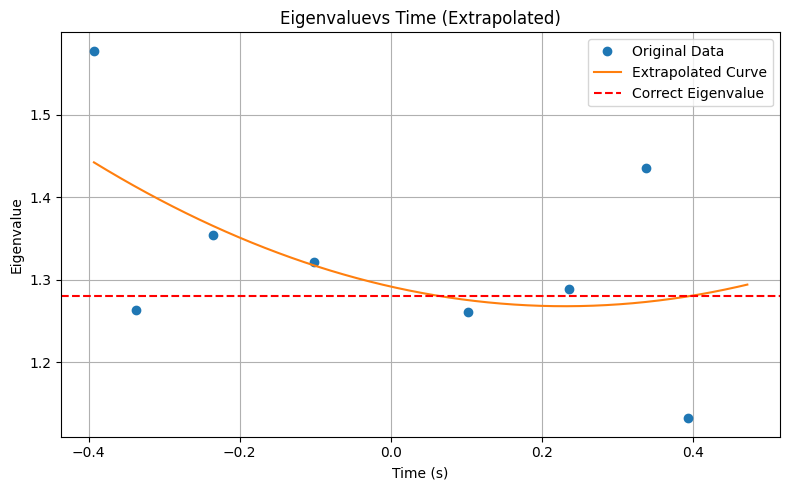

Exact Eigenvalue: 2.561249694973137
Alpha: 3.6
Num Ancilla: 10
Y-intercept at x = 0: 2.8076368438994246
Correct eigenvalue: 2.561249694973137
Error ratio: 0.09619801982206652


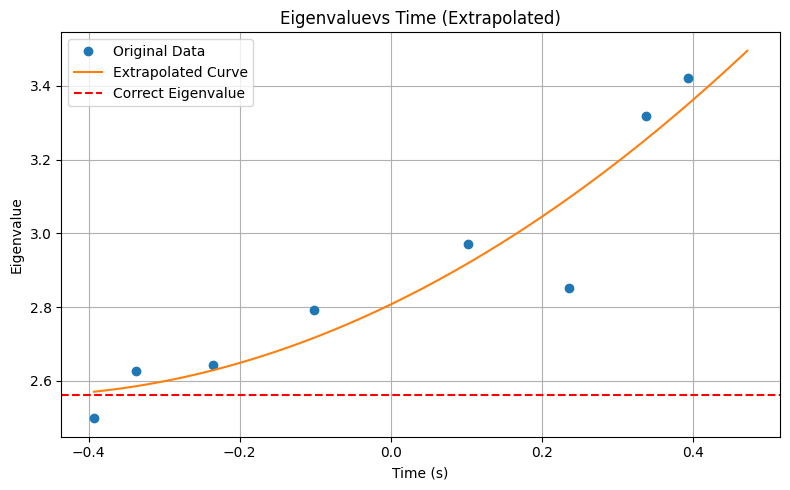

In [23]:
for group_name, group in df.groupby("Exact Eigenvalue"):
    exact_eigenvalue = ast.literal_eval(group_name).real
    print(f"Exact Eigenvalue: {exact_eigenvalue}")
    alpha = group["Alpha"].iloc[0]
    print(f"Alpha: {alpha}")
    num_ancilla = group["Num Ancilla"].iloc[0]
    print(f"Num Ancilla: {num_ancilla}")

    # remove rows with the smalles and largest time values
    
    x = group["Time"].values
    y = group["Estimated Eigenvalue"].values
    # Fit a 2nd-degree polynomial (adjust degree if needed)
    degree = 2
    coeffs = Polynomial.fit(x, y, degree).convert().coef

    y_intercept = coeffs[0]
    print(f"Y-intercept at x = 0: {y_intercept}")
    print(f"Correct eigenvalue: {exact_eigenvalue}")
    print(f"Error ratio: {abs(exact_eigenvalue - y_intercept) / exact_eigenvalue}")

    # Extrapolation range (extend 20% beyond the last x)
    x_extra = np.linspace(x.min(), x.max() * 1.2, 200)
    y_extra = sum(c * x_extra**i for i, c in enumerate(coeffs))



    # Plot original and extrapolated data
    plt.figure(figsize=(8, 5))
    plt.plot(x, y, 'o', label='Original Data')
    plt.plot(x_extra, y_extra, '-', label='Extrapolated Curve')
    plt.axhline(y=exact_eigenvalue, color='r', linestyle='--', label='Correct Eigenvalue')
    plt.xlabel("Time (s)")
    plt.ylabel("Eigenvalue")
    plt.title("Eigenvaluevs Time (Extrapolated)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [63]:
df_6_nodes_just_positive = pd.read_csv(r"C:\Users\Ro\Desktop\qDriftExtraPolation\qdrift_ising_model_5_nodes_2025-07-10.csv")
df_6_nodes_just_positive

,Num Qubits,Time,Shots,Num Ancilla,Exact Eigenvalue,Expected Phase,Most Probable Bitstring,Estimated Phase,Estimated Eigenvalue,Eigenvalue Error,...,type of Hamiltonian,Num Random Circuits,Num Shots per Circuit,Circuit Depth,Raw results,estimnated energies counts,max energy,min energy,stdev energy,mean energy
0,2,0.574472,100,11,(1.2806248474865685+0j),0.117088,100001011,0.131836,1.441932,0.161307,...,Ising,100,1,2050,"{'00110100101': 1, '11100001111': 1, '00010000...","{np.float64(2.2483451332016036): 1, np.float64...",5.441957,-4.672926,2.023595,1.036375
1,2,0.716075,100,11,(1.2806248474865685+0j),0.145949,100100011,0.184082,1.615224,0.334599,...,Ising,100,1,2050,"{'00100100011': 2, '00110110111': 1, '01001001...","{np.float64(1.246764360010587): 2, np.float64(...",4.254423,-4.314405,1.591541,1.287381
2,2,0.790520,100,11,(1.2806248474865685+0j),0.161122,110100000,0.187500,1.490281,0.209657,...,Ising,100,1,2050,"{'00100010011': 1, '01001100010': 1, '00111011...","{np.float64(1.0672587785024836): 1, np.float64...",3.613156,-3.974084,1.591499,1.165136
3,2,0.790520,100,11,(2.561249694973137+0j),0.322244,1110111100,0.460205,3.657787,1.096537,...,Ising,100,1,2050,"{'01110011110': 2, '01110111011': 3, '01110111...","{np.float64(3.5937513777938177): 2, np.float64...",3.962441,-3.954679,2.592018,2.431798
4,2,0.379573,100,11,(2.561249694973137+0j),0.154727,1000011,0.190918,3.160325,0.599075,...,Ising,100,1,2050,"{'00100111100': 1, '01100100001': 1, '00101100...","{np.float64(2.5541244055956036): 1, np.float64...",7.840192,-8.195830,4.038020,2.060596
5,2,0.716075,100,11,(2.561249694973137+0j),0.291898,1110001010,0.382080,3.352554,0.791304,...,Ising,100,1,2050,"{'00011000111': 1, '10001100000': 1, '01011111...","{np.float64(0.8525983080484771): 1, np.float64...",4.357249,-4.271560,2.962349,1.813035
6,2,0.379573,100,11,(1.2806248474865685+0j),0.077364,11000110,0.075195,1.244732,0.035893,...,Ising,100,1,2050,"{'00001000011': 1, '11100010100': 1, '01101110...","{np.float64(0.5415390353636248): 1, np.float64...",7.128917,-8.220078,2.850282,0.888447
7,2,0.574472,100,11,(2.561249694973137+0j),0.234175,1010011000,0.320557,3.506030,0.944780,...,Ising,100,1,2050,"{'01010011000': 2, '01100110101': 1, '00011100...","{np.float64(3.546083535500867): 2, np.float64(...",5.441957,-5.415254,3.210538,2.034245
8,2,0.150455,100,11,(2.561249694973137+0j),0.061331,10001100,0.067139,2.803802,0.242552,...,Ising,100,1,2050,"{'00010110111': 1, '00010100111': 1, '00001110...","{np.float64(3.7316054106920156): 1, np.float64...",19.534852,-17.985115,5.730312,1.536076
9,2,0.150455,100,11,(1.2806248474865685+0j),0.030665,1000001,0.031250,1.305042,0.024417,...,Ising,100,1,2050,"{'11110101110': 1, '01111000000': 1, '11111101...","{np.float64(-1.6720854845723783): 1, np.float6...",19.636809,-13.295119,4.468328,1.941658


Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 11
Y-intercept at x = 0: 1.2564816554726428
Correct eigenvalue: 1.2806248474865685
Error ratio: 0.018852665604068636
Exact Eigenvalue: 2.561249694973137
Alpha: 3.6
Num Ancilla: 11
Y-intercept at x = 0: 2.9113092329367247
Correct eigenvalue: 2.561249694973137
Error ratio: 0.13667528732190218


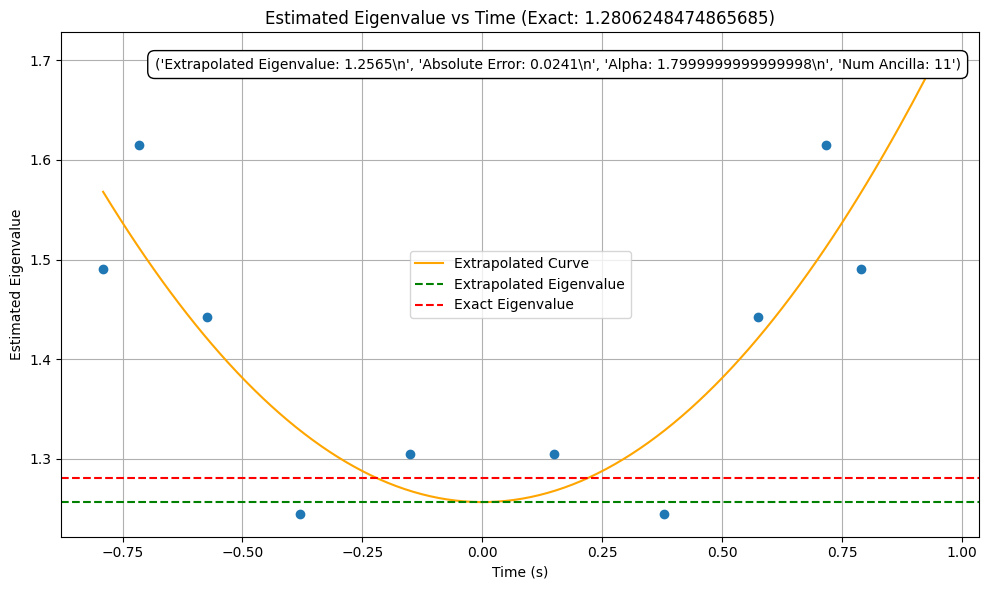

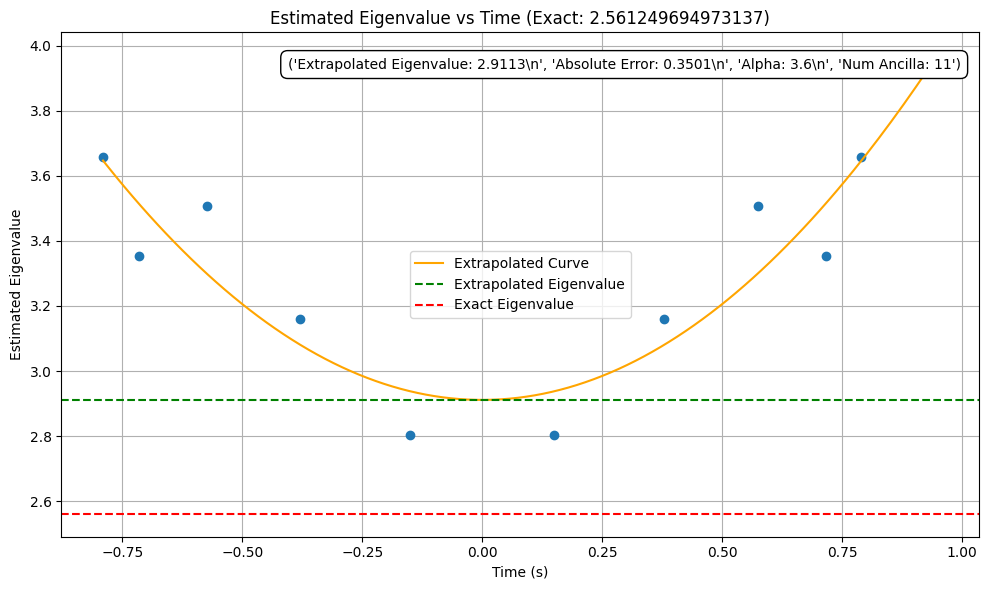

In [ ]:
for group_name, group in df_6_nodes_just_positive.groupby("Exact Eigenvalue"):
    exact_eigenvalue = ast.literal_eval(group_name).real
    print(f"Exact Eigenvalue: {exact_eigenvalue}")
    alpha = group["Alpha"].iloc[0]
    print(f"Alpha: {alpha}")
    num_ancilla = group["Num Ancilla"].iloc[0]
    print(f"Num Ancilla: {num_ancilla}")

    stdevs = group["stdev energy"]
    # mirror the results across the y-axis to duplicte the data (phyics math moment)
    df_mirror = group.copy()
    df_mirror["Time"] = -df_mirror["Time"]
    group = pd.concat([group, df_mirror])

    # Calculate theoretical upper bound for standard deviation
    stdev_theoretical_upper_bound = (alpha ** 2 * group["Time"] ** 2) * (2 ** (num_ancilla) - 1)


    plt.figure(figsize=(10, 6))
    plt.plot(group["Time"], group["Estimated Eigenvalue"], marker='o', linestyle='None')
    # fit a polynomial to the data
    coeffs = Polynomial.fit(group["Time"], group["Estimated Eigenvalue"], 2).convert().coef
    y_intercept = coeffs[0]
    print(f"Y-intercept at x = 0: {y_intercept}")
    print(f"Correct eigenvalue: {exact_eigenvalue}")
    print(f"Error ratio: {abs(exact_eigenvalue - y_intercept) / exact_eigenvalue}")
    # Extrapolation range (extend 20% beyond the last x)
    x_extra = np.linspace(group["Time"].min(), group["Time"].max() * 1.2, 200)
    y_extra = sum(c * x_extra**i for i, c in enumerate(coeffs))
    plt.plot(x_extra, y_extra, label='Extrapolated Curve', color='orange')
    plt.axhline(y=y_intercept, color='g', linestyle='--', label='Extrapolated Eigenvalue')
    plt.axhline(y=exact_eigenvalue, color='r', linestyle='--', label='Exact Eigenvalue')
    plt.xlabel("Time (s)")
    plt.ylabel("Estimated Eigenvalue")
    plt.title(f"Estimated Eigenvalue vs Time (Exact: {exact_eigenvalue})")
    #add textbox info about the extrapolated eigenvalue 
    stats_text = (f"Extrapolated Eigenvalue: {y_intercept:.4f}\n" f"Absolute Error: {abs(exact_eigenvalue - y_intercept):.4f}\n"
                    f"Alpha: {alpha}\n"
                    f"Num Ancilla: {num_ancilla}")
    plt.text(0.98, 0.95, stats_text, ha='right', va='top', transform=plt.gca().transAxes,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))
    plt.grid(True)
    plt.tight_layout()
    plt.legend()

Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 10


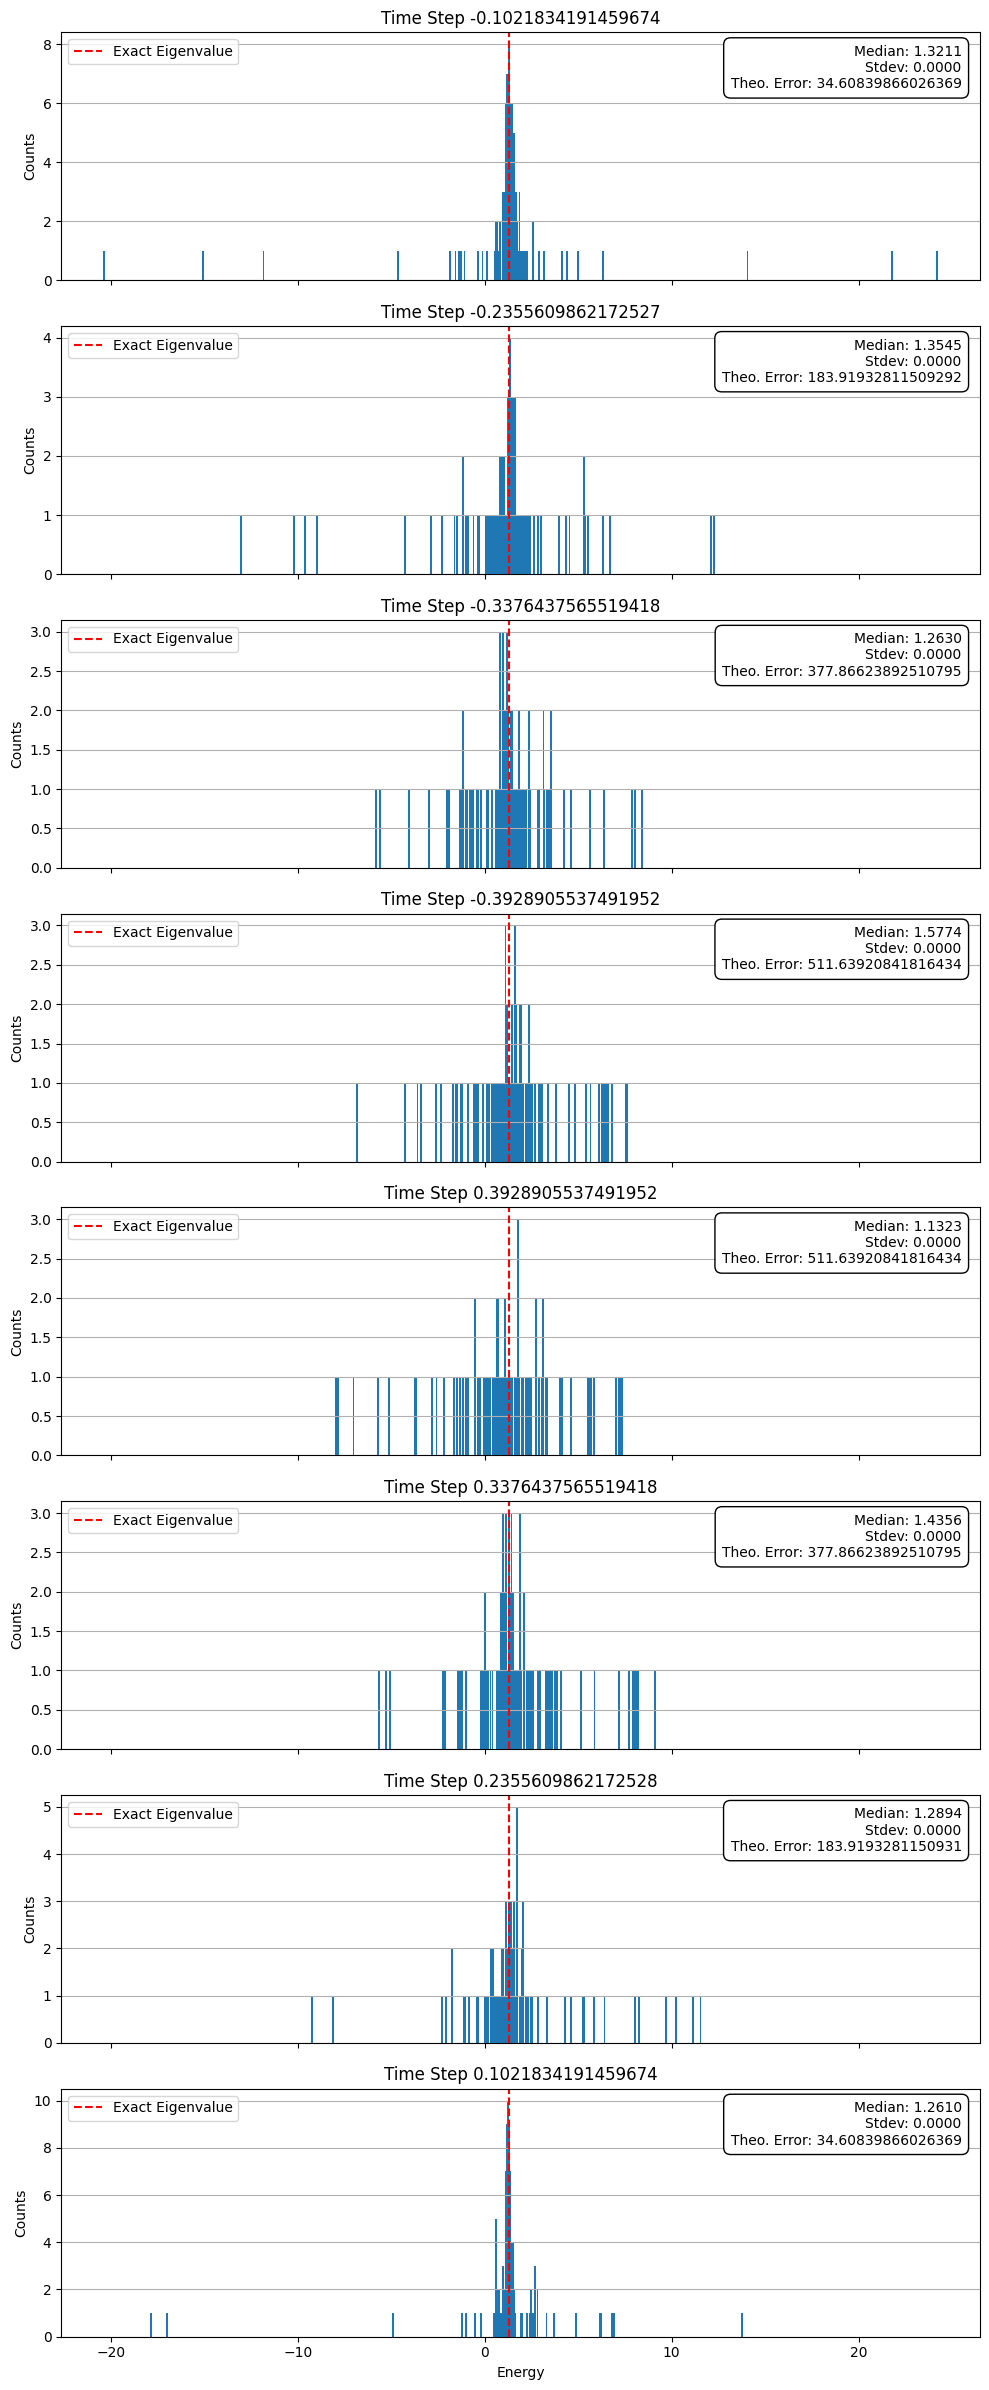

Exact Eigenvalue: 2.561249694973137
Alpha: 3.6
Num Ancilla: 10


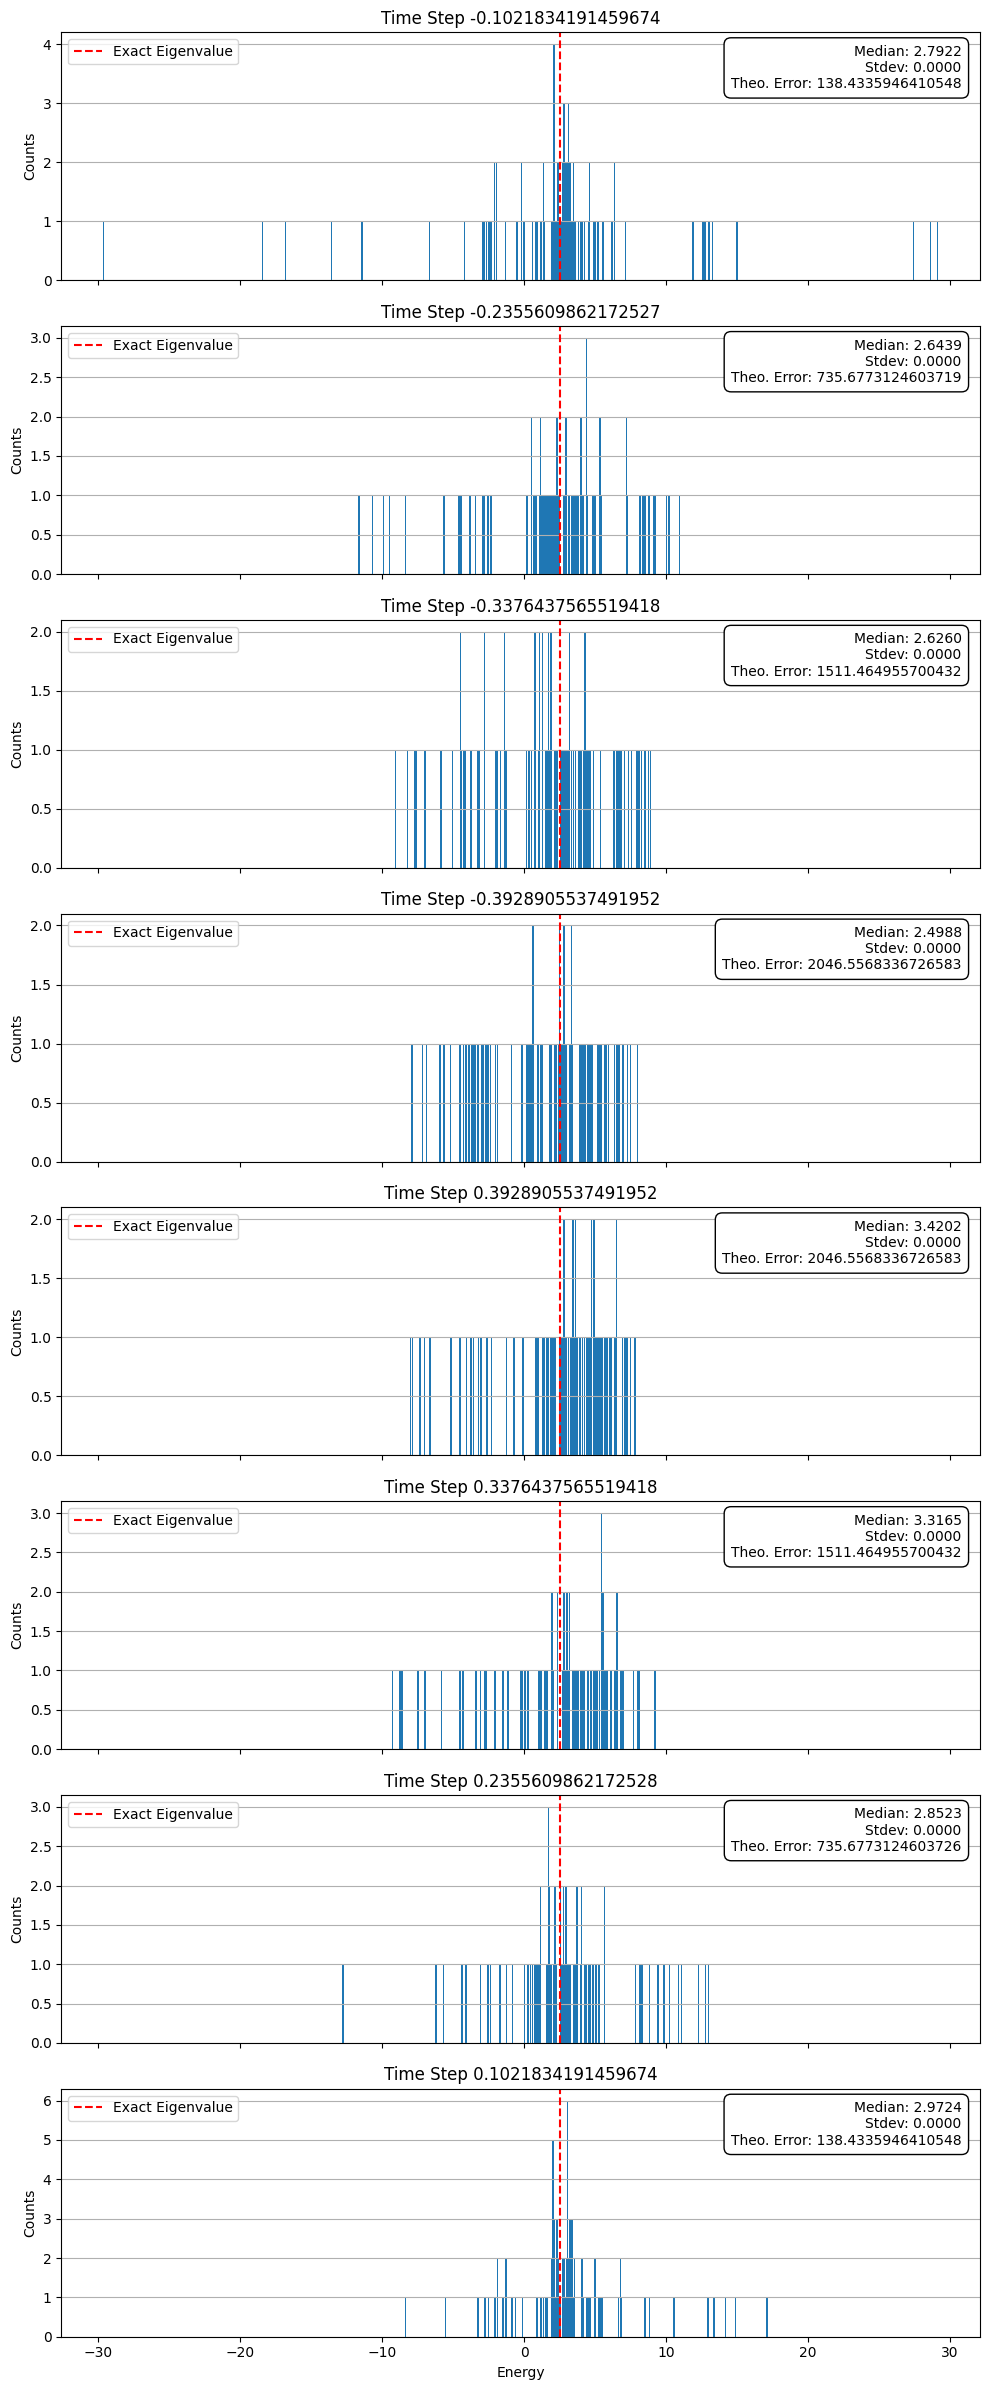

In [57]:

def plot_energy_histograms(group, exact_eigenvalue, theoretical_error, energy_counts_column="estimnated energies counts", time_column="Time"):
    """
    Plots histograms of estimated energy counts over time steps, with a text box showing
    median, standard deviation, and theoretical error.

    Parameters:
    - group: DataFrame containing energy counts and time values.
    - exact_eigenvalue: Float, value of the exact eigenvalue to mark.
    - theoretical_error: Float or list of floats for theoretical error(s) per time step.
    - energy_counts_column: Name of the column containing energy counts dictionaries.
    - time_column: Name of the column containing time step identifiers.
    """
    all_counts = group[energy_counts_column].values

    # Clean and parse
    c_cleaned = [x.replace("np.float64(", "").replace(")", "") for x in all_counts]
    counts = [ast.literal_eval(x) for x in c_cleaned]
    time_vals = group[time_column].values

    # Collect all possible energies
    all_estimated_energies = sorted(set(energy for count in counts for energy in count.keys()))

    num_times = len(counts)
    fig, axes = plt.subplots(num_times, 1, figsize=(10, 3 * num_times), sharex=True)

    if num_times == 1:
        axes = [axes]  # Ensure iterable

    # Handle theoretical_error as scalar or list
    if np.isscalar(theoretical_error):
        theoretical_error = [theoretical_error] * num_times

    for idx, (ax, count, time_val, theo_err) in enumerate(zip(axes, counts, time_vals, theoretical_error)):
        counts_for_energies = [count.get(energy, 0) for energy in all_estimated_energies]
        ax.bar(all_estimated_energies, counts_for_energies, width=0.1)
        ax.set_title(f"Time Step {time_val}")
        ax.set_ylabel("Counts")
        ax.grid(True, axis='y')
        ax.axvline(x=exact_eigenvalue, color='r', linestyle='--', label='Exact Eigenvalue')
        ax.legend()

        # Weighted statistics
        energies = np.array(all_estimated_energies)
        counts_array = np.array(counts_for_energies)
        flatten_counts = np.repeat(energies, counts_array.astype(int))
        if counts_array.sum() > 0:
            median = np.median(flatten_counts)
            stdev = np.std(median)
            
        else:
            median = np.nan
            stdev = np.nan

        # Add text box
        stats_text = (f"Median: {median:.4f}\n"
                      f"Stdev: {stdev:.4f}\n"
                      f"Theo. Error: {theo_err}")
        ax.text(0.98, 0.95, stats_text, ha='right', va='top', transform=ax.transAxes,
                bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

    axes[-1].set_xlabel("Energy")

    plt.tight_layout()
    plt.show()

for group_name, group in df_results.groupby("Exact Eigenvalue"):
    exact_eigenvalue = ast.literal_eval(group_name).real
    print(f"Exact Eigenvalue: {exact_eigenvalue}")
    alpha = group["Alpha"].iloc[0]
    print(f"Alpha: {alpha}")
    num_ancilla = group["Num Ancilla"].iloc[0]
    print(f"Num Ancilla: {num_ancilla}")

    stdevs = group["stdev energy"]
    stdev_theoretical_upper_bound = (alpha ** 2 * group["Time"] ** 2) * (2 ** (num_ancilla) - 1)

    plot_energy_histograms(group, exact_eigenvalue, stdev_theoretical_upper_bound)